# Section 1: Exploratory Data Analysis EDA

## Phase 1: Data Health, Cleaning, Manipulating, Preparing

### 1. Importing Libraries and Loading Data

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy as sp
import zipfile 
import os
import kagglehub
from dotenv import load_dotenv
print('libraries imported!')

libraries imported!


In [11]:
load_dotenv()
zip_path = os.getenv('ZIP_PATH')
csv_path = os.getenv('CSV_PATH')

if not os.path.exists(csv_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref :
        zip_ref.extractall("data/")
    print('Extraction done!')
else :
    print('zip file already extracted!')

zip file already extracted!


### 2. Initial Data Inspection

In [12]:
df = pd.read_csv(csv_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   year                   1000000 non-null  int64  
 1   quarter                1000000 non-null  str    
 2   company                1000000 non-null  str    
 3   industry               1000000 non-null  str    
 4   region                 1000000 non-null  str    
 5   department             1000000 non-null  str    
 6   economic_condition     1000000 non-null  str    
 7   work_model             1000000 non-null  str    
 8   inflation_rate         1000000 non-null  float64
 9   interest_rate          1000000 non-null  float64
 10  gdp_growth             1000000 non-null  float64
 11  ai_adoption_score      1000000 non-null  int64  
 12  automation_level       1000000 non-null  int64  
 13  employees_hired        1000000 non-null  int64  
 14  layoffs                1000000

In [13]:
df.describe()

,year,inflation_rate,interest_rate,gdp_growth,ai_adoption_score,automation_level,employees_hired,layoffs,attrition_rate,employee_satisfaction,avg_salary,revenue_growth,stock_growth,productivity_index,innovation_score,layoff_risk_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,990000.000000,990000.000000,990000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2015.501059,4.059324,3.506190,2.997288,28.982024,29.109442,6046.851745,1970.385495,15.946582,65.070168,80261.371138,4.956334,4.976125,68.652561,71.315736,36.224992
std,6.347227,1.883837,1.488236,2.500446,20.988087,22.249484,3437.105021,1670.457790,5.986126,12.825780,29744.848938,11.925981,16.926276,11.186697,15.451910,29.373006
min,2005.000000,1.000000,0.000000,-8.000000,0.000000,0.000000,100.000000,0.000000,2.000000,1.000000,30000.000000,-40.000000,-60.000000,6.300000,1.000000,0.000000
25%,2010.000000,2.650000,2.490000,1.310000,13.000000,11.000000,3071.000000,849.000000,11.890000,57.200000,57847.000000,-3.000000,-6.400000,61.300000,60.800000,11.400000
50%,2016.000000,4.000000,3.500000,3.000000,25.000000,25.000000,6040.000000,1698.000000,15.670000,65.600000,78095.000000,5.060000,5.040000,68.700000,71.500000,32.100000
75%,2021.000000,5.350000,4.510000,4.680000,42.000000,43.000000,9025.000000,2549.000000,19.620000,73.700000,100737.000000,13.020000,16.410000,76.200000,82.300000,54.200000
max,2026.000000,14.310000,10.800000,12.000000,100.000000,100.000000,11999.000000,16077.000000,45.000000,100.000000,217594.000000,70.250000,90.930000,100.000000,100.000000,100.000000


### 3. Checking for Duplicates

In [14]:
df[df.duplicated()]

,year,quarter,company,industry,region,department,economic_condition,work_model,inflation_rate,interest_rate,...,employees_hired,layoffs,attrition_rate,employee_satisfaction,avg_salary,revenue_growth,stock_growth,productivity_index,innovation_score,layoff_risk_score


### 4. Variable Categorization (Discrete, Continuous, Categorical)

In [15]:
discrete_variables = []
continuous_variables = []
categorical_variables = []

for var in df.columns :
    #variables
    col = df[var]
    unique_values = col.unique().tolist()
    distinct = len(unique_values)

    #conditions
    is_decimal = (col.dtype == 'float64')
    is_int = (col.dtype == 'int64')
    is_string = (col.dtype == 'str')

    if is_int or is_decimal :
        fractional_part_not_null = ((col.dropna() % 1 != 0).any())
        fractional_part_is_null = ((col.dropna() % 1 == 0).all())

    #logic
    if is_string :
        categorical_variables.append(var)

    elif (is_int or (is_decimal and fractional_part_is_null)) and (distinct < 10):
        discrete_variables.append(var)

    elif ((is_int or (is_decimal and fractional_part_is_null)) and distinct >= 10) or (is_decimal and fractional_part_not_null):
        continuous_variables.append(var)
    
        
    else:
        print(var, "is unknown")
categories = ['discrete', 'continuous', 'categorical']
for cat in categories :
    liste = globals()[f'{cat}_variables']
    if len(liste) == 0 :
        print(f'There is no {cat.capitalize()} variables in this dataframe')
    else : 
        print(f"{cat.capitalize()} variables :\n{liste}\n")


There is no Discrete variables in this dataframe
Continuous variables :
['year', 'inflation_rate', 'interest_rate', 'gdp_growth', 'ai_adoption_score', 'automation_level', 'employees_hired', 'layoffs', 'attrition_rate', 'employee_satisfaction', 'avg_salary', 'revenue_growth', 'stock_growth', 'productivity_index', 'innovation_score', 'layoff_risk_score']

Categorical variables :
['quarter', 'company', 'industry', 'region', 'department', 'economic_condition', 'work_model']



### 5. Checking Unique Values

In [16]:
dict = {}
for col in df.columns :
    if df[col].dtype == 'str' or 'year' in col.lower():
        unique_values = df[col].unique()\
                                .tolist()
        unique_values.sort()
        dict[col] = unique_values
        print(f'For column "{col.upper()}" unique values are :\n{dict[col]}\n')

For column "YEAR" unique values are :
[2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

For column "QUARTER" unique values are :
['Q1', 'Q2', 'Q3', 'Q4']

For column "COMPANY" unique values are :
['ApexAI', 'ByteFusion', 'CloudSphere', 'CyberWave', 'DataNest', 'FutureGrid', 'NeuroLink Systems', 'PixelCore', 'QuantumEdge', 'TechNova']

For column "INDUSTRY" unique values are :
['AI', 'Cloud Computing', 'Cybersecurity', 'Data Analytics', 'E-Commerce', 'FinTech', 'Gaming', 'Software']

For column "REGION" unique values are :
['Asia-Pacific', 'Europe', 'Middle East', 'North America', 'South America']

For column "DEPARTMENT" unique values are :
['Data Science', 'Engineering', 'Finance', 'HR', 'Marketing', 'Operations', 'Product', 'Sales']

For column "ECONOMIC_CONDITION" unique values are :
['AI Boom', 'Growth', 'Pandemic', 'Recession', 'Slowdown', 'Stable']

For column "WORK_MODEL" unique values are :
['Hy

### 6. Data Type Optimization

In [17]:
for col in categorical_variables:
    df[col] = df[col].astype('category')
print("All categorical variables have dtype 'category' instead of 'string'")

All categorical variables have dtype 'category' instead of 'string'


### 7. Handling Missing Values (Imputation)

In [18]:
df['avg_salary'] = df['avg_salary'].fillna(df.groupby(['department', 'region'])['avg_salary'].transform('median'))
df['revenue_growth'] = df['revenue_growth'].fillna(df.groupby(['industry', 'year'])['revenue_growth'].transform('median'))
df['employee_satisfaction'] = df['employee_satisfaction'].fillna(df.groupby(['department', 'company'])['employee_satisfaction'].transform('median'))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   year                   1000000 non-null  int64   
 1   quarter                1000000 non-null  category
 2   company                1000000 non-null  category
 3   industry               1000000 non-null  category
 4   region                 1000000 non-null  category
 5   department             1000000 non-null  category
 6   economic_condition     1000000 non-null  category
 7   work_model             1000000 non-null  category
 8   inflation_rate         1000000 non-null  float64 
 9   interest_rate          1000000 non-null  float64 
 10  gdp_growth             1000000 non-null  float64 
 11  ai_adoption_score      1000000 non-null  int64   
 12  automation_level       1000000 non-null  int64   
 13  employees_hired        1000000 non-null  int64   
 14  layoffs       

## Phase 2: Visualizing Data using Seaborn and Matplotlib

### 1. HeatMap : Visualizing the correlation between dataframe elements 

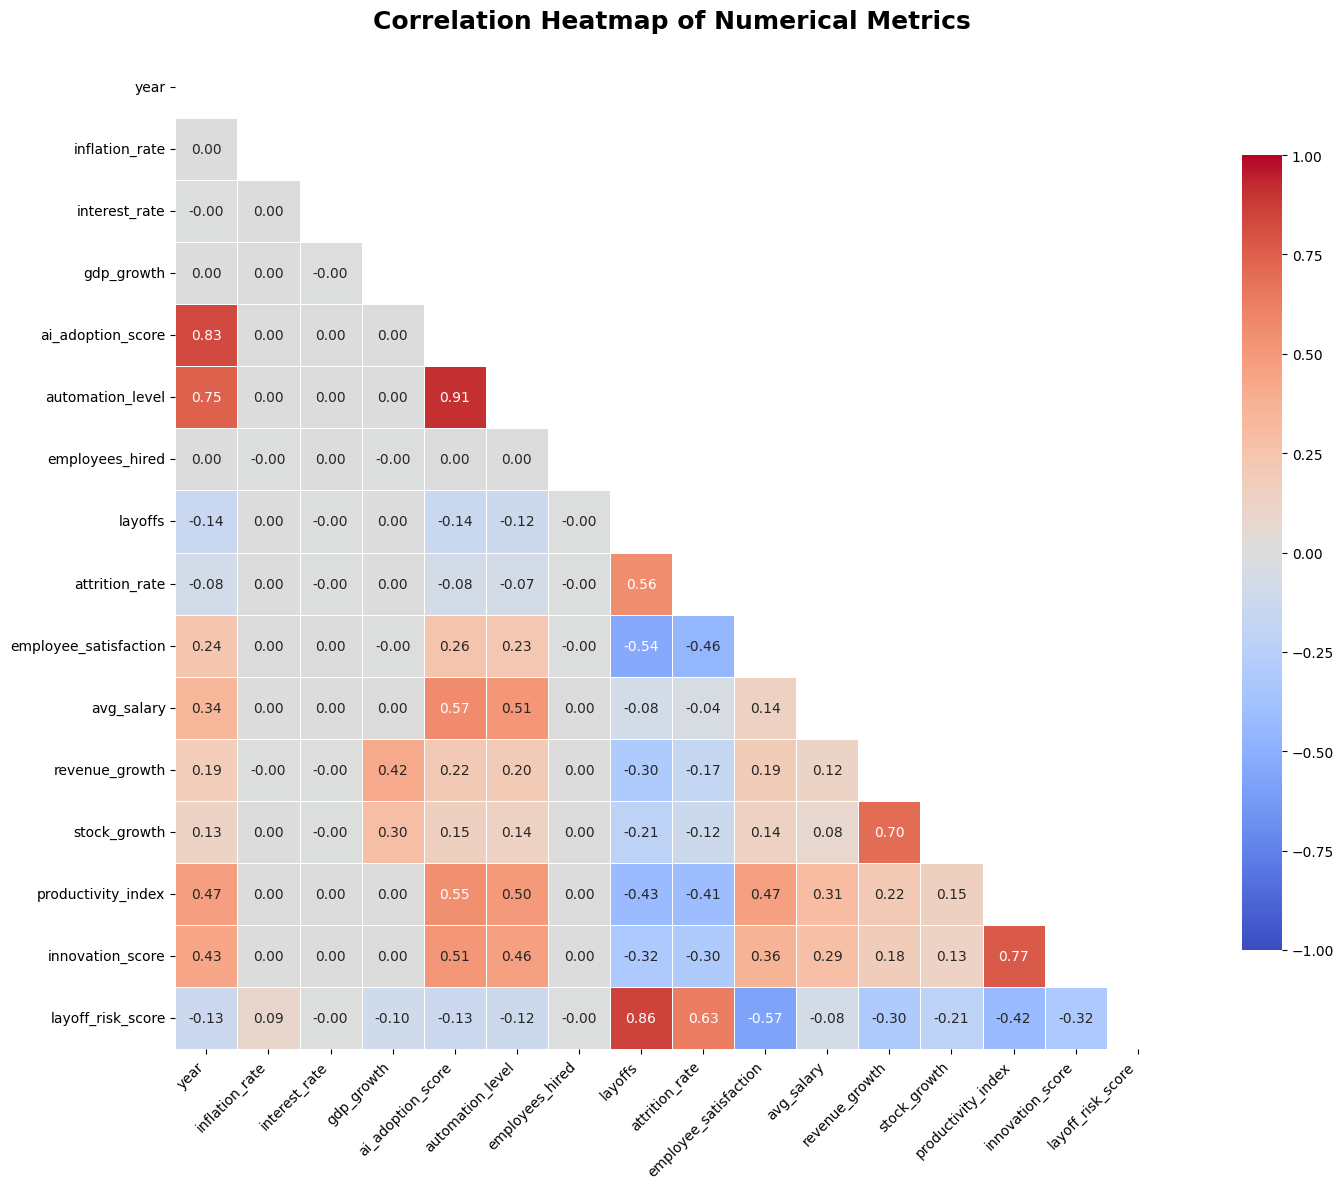

In [19]:
# 1. Select only the numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# 3. Create a mask to hide the upper triangle (removes duplicate visual clutter)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Set up the figure size
plt.figure(figsize=(16, 12))

# 5. Draw the heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='coolwarm',       # Blue for negative, Red for positive correlation
            vmax=1.0,              # Max correlation
            vmin=-1.0,             # Min correlation
            center=0,              # Center at 0 (white)
            annot=True,            # Show the actual numbers
            fmt='.2f',             # Round to 2 decimal places
            square=True,           # Make the boxes perfectly square
            linewidths=0.5,        # Add lines between boxes
            cbar_kws={"shrink": 0.8}) # Shrink the colorbar slightly to match the height

# Add titles and format the labels
plt.title('Correlation Heatmap of Numerical Metrics', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Display the plot cleanly
plt.tight_layout()
plt.show()

### 2. Time-Series & Macro Trends :

#### 2.1. Technological Evolution Trends (The Modernization Shift) :

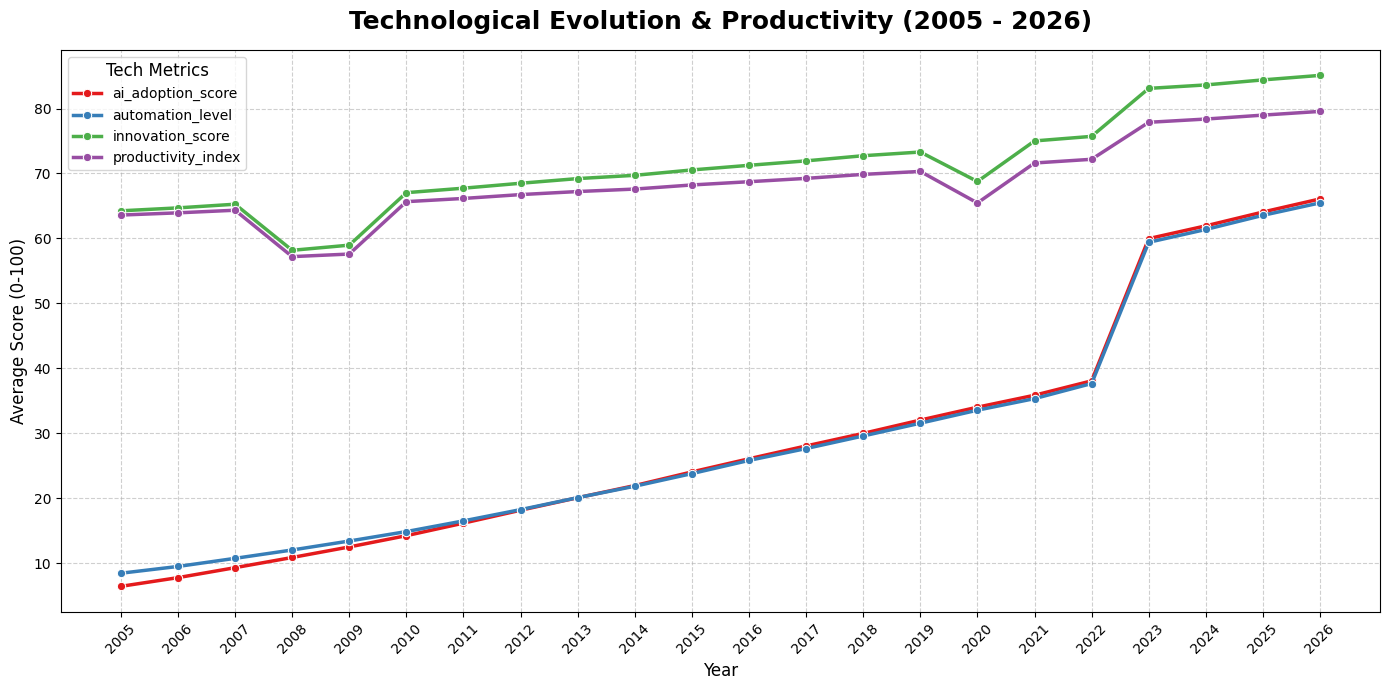

In [ ]:
# 1. Define the metrics for this specific category
tech_metrics = ['ai_adoption_score', 'automation_level', 'innovation_score', 'productivity_index']

# 2. Group by Year and get the mean (average) for each metric
tech_yearly_avg = df.groupby('year')[tech_metrics].mean().reset_index()

# 3. "Melt" the data (This makes it incredibly easy for Seaborn to draw multiple lines)
tech_melted = tech_yearly_avg.melt(id_vars='year', 
                                   var_name='Metric', 
                                   value_name='Average Score')


plt.figure(figsize=(14, 7))
sns.lineplot(data=tech_melted, 
             x='year', 
             y='Average Score', 
             hue='Metric', 
             marker='o',         
             linewidth=2.5,      
             palette='Set1')     

plt.title('Technological Evolution & Productivity (2005 - 2026)', fontsize=18, 
                                                                  fontweight='bold',
                                                                  pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Score (0-100)', fontsize=12)
plt.xticks(tech_yearly_avg['year'], rotation=45) # Forces the X-axis to show every single year
plt.legend(title='Tech Metrics', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 

plt.tight_layout()
plt.show()

### 2.2 HR & Sentiment Trends (The Human Element) :

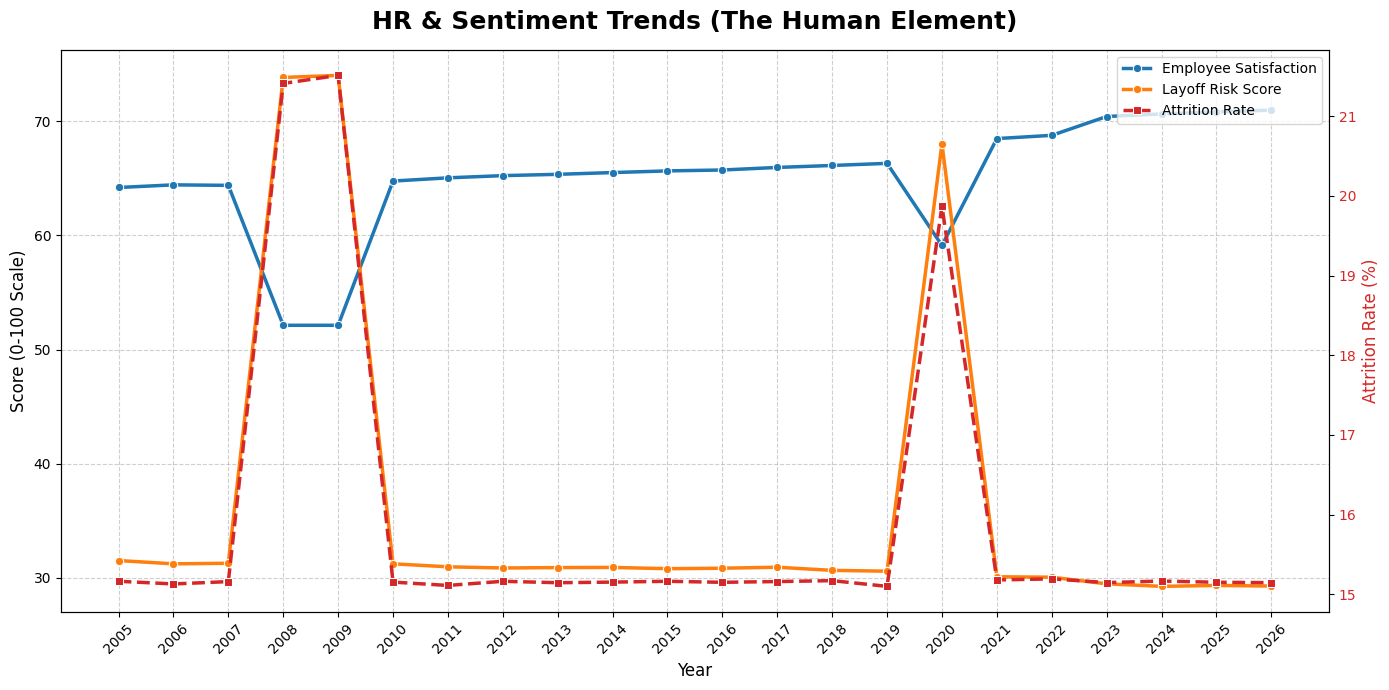

In [25]:
# 1. Group by Year and get the mean for the HR metrics
hr_metrics = ['employee_satisfaction', 'layoff_risk_score', 'attrition_rate']
hr_yearly_avg = df.groupby('year')[hr_metrics].mean().reset_index()

# 2. Set up the primary plot (ax1)
fig, ax1 = plt.subplots(figsize=(14, 7))

# 3. Plot the 0-100 metrics on the left axis (ax1)
sns.lineplot(data=hr_yearly_avg, x='year', y='employee_satisfaction', 
             ax=ax1, color='#1f77b4', label='Employee Satisfaction', marker='o', linewidth=2.5)
sns.lineplot(data=hr_yearly_avg, x='year', y='layoff_risk_score', 
             ax=ax1, color='#ff7f0e', label='Layoff Risk Score', marker='o', linewidth=2.5)

# Format the left axis
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Score (0-100 Scale)', fontsize=12, color='black')
ax1.set_title('HR & Sentiment Trends (The Human Element)', fontsize=18, fontweight='bold', pad=15)
ax1.set_xticks(hr_yearly_avg['year'])
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.6)

# 4. Create the secondary Y-axis (ax2) on the right side
ax2 = ax1.twinx()

# 5. Plot Attrition Rate on the right axis (ax2)
# Using a dashed line and squares ('s') to make it visually distinct
sns.lineplot(data=hr_yearly_avg, x='year', y='attrition_rate', 
             ax=ax2, color='#d62728', label='Attrition Rate', marker='s', linewidth=2.5, linestyle='--')

# Format the right axis
ax2.set_ylabel('Attrition Rate (%)', fontsize=12, color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

# 6. Combine the legends so they aren't separated
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=10)
ax2.get_legend().remove() # Removes the duplicate legend

plt.tight_layout()
plt.show()


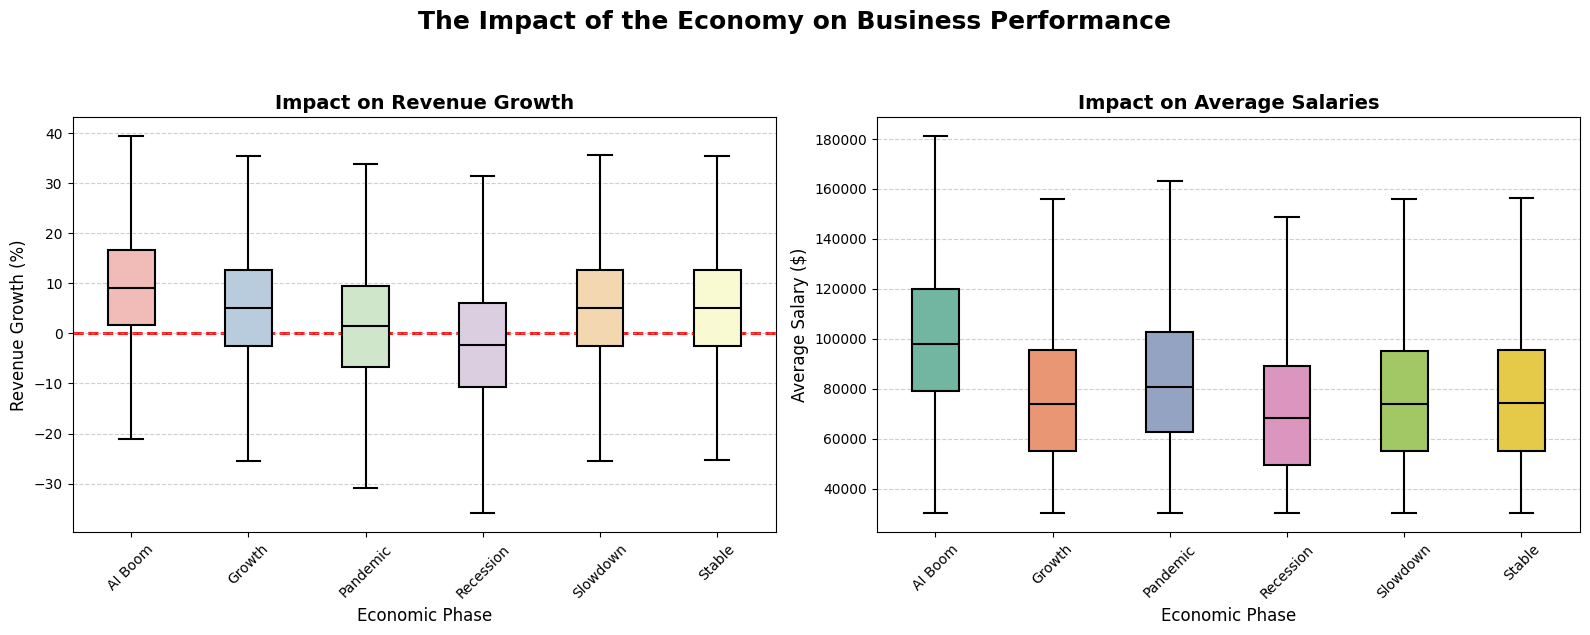

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Revenue Growth
sns.boxplot(data = df,
            x='economic_condition',
            y='revenue_growth', 
            hue='economic_condition',
            dodge=False,
            legend = False,
            ax = axes[0],
            palette='Pastel1',
            showfliers = False,
            width = 0.4, 
            linewidth=1.5,
            linecolor='black') 

axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, zorder=0)

axes[0].set_title('Impact on Revenue Growth', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Economic Phase', fontsize=12)
axes[0].set_ylabel('Revenue Growth (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)

#==================================================================
# Chart 2: Average Salary

sns.boxplot(data=df, x='economic_condition', y='avg_salary', 
            hue='economic_condition', legend=False, dodge=False,
            ax=axes[1], palette='Set2', showfliers=False, width= 0.4, 
            linewidth=1.5, linecolor='black')

axes[1].set_title('Impact on Average Salaries', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Economic Phase', fontsize=12)
axes[1].set_ylabel('Average Salary ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.suptitle('The Impact of the Economy on Business Performance', fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()


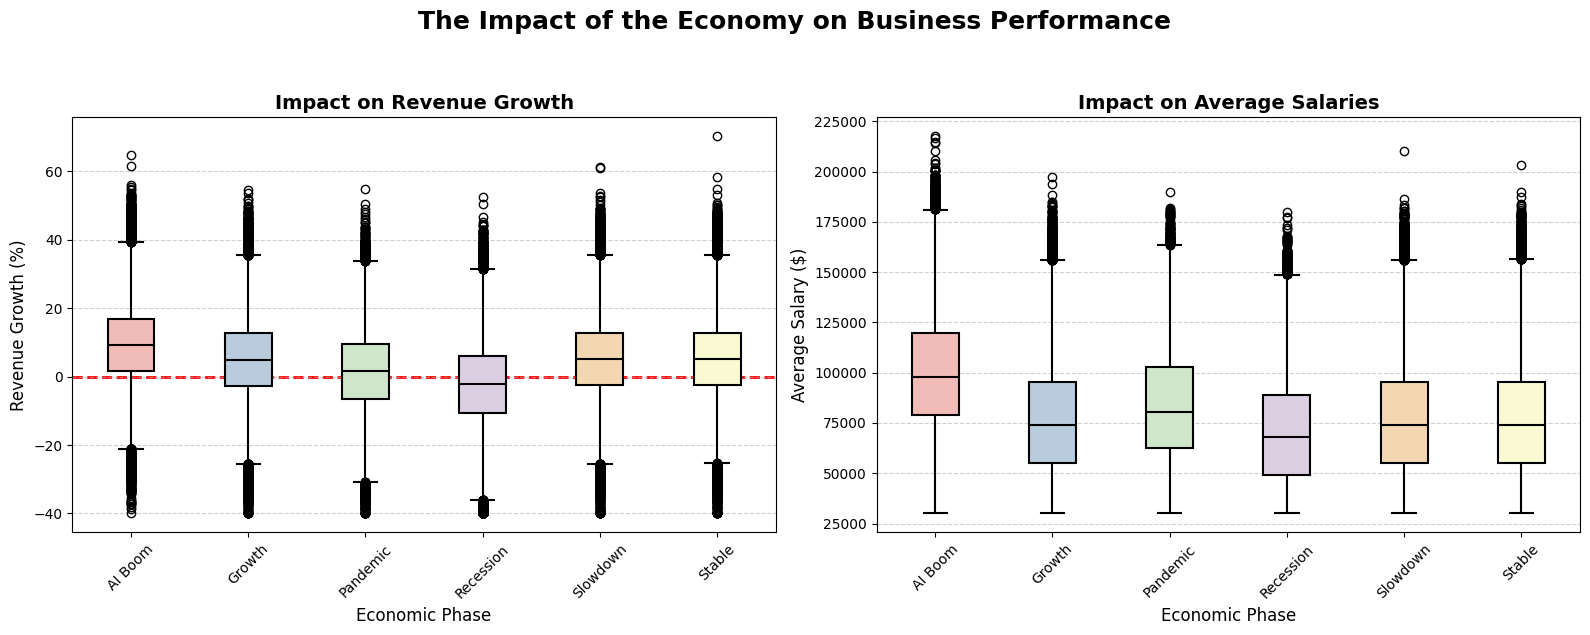

In [ ]:
y_value = ['revenue_growth', 'avg_salary']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(y_value) :
    sns.boxplot(data = df,
            x = 'economic_condition',
            y = col,
            hue='economic_condition',
            dodge=False,
            legend = False,
            ax = axes[i],
            palette='Pastel1',
            #showfliers = False, 
            width = 0.4, 
            linewidth=1.5,
            linecolor='black')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.6)

axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, zorder=0)

# layout display for revenue_growth chart :
axes[0].set_title('Impact on Revenue Growth', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Economic Phase', fontsize=12)
axes[0].set_ylabel('Revenue Growth (%)', fontsize=12)

# layout display for avg_salary chart  :
axes[1].set_title('Impact on Average Salaries', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Economic Phase', fontsize=12)
axes[1].set_ylabel('Average Salary ($)', fontsize=12)

plt.suptitle('The Impact of the Economy on Business Performance', fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()


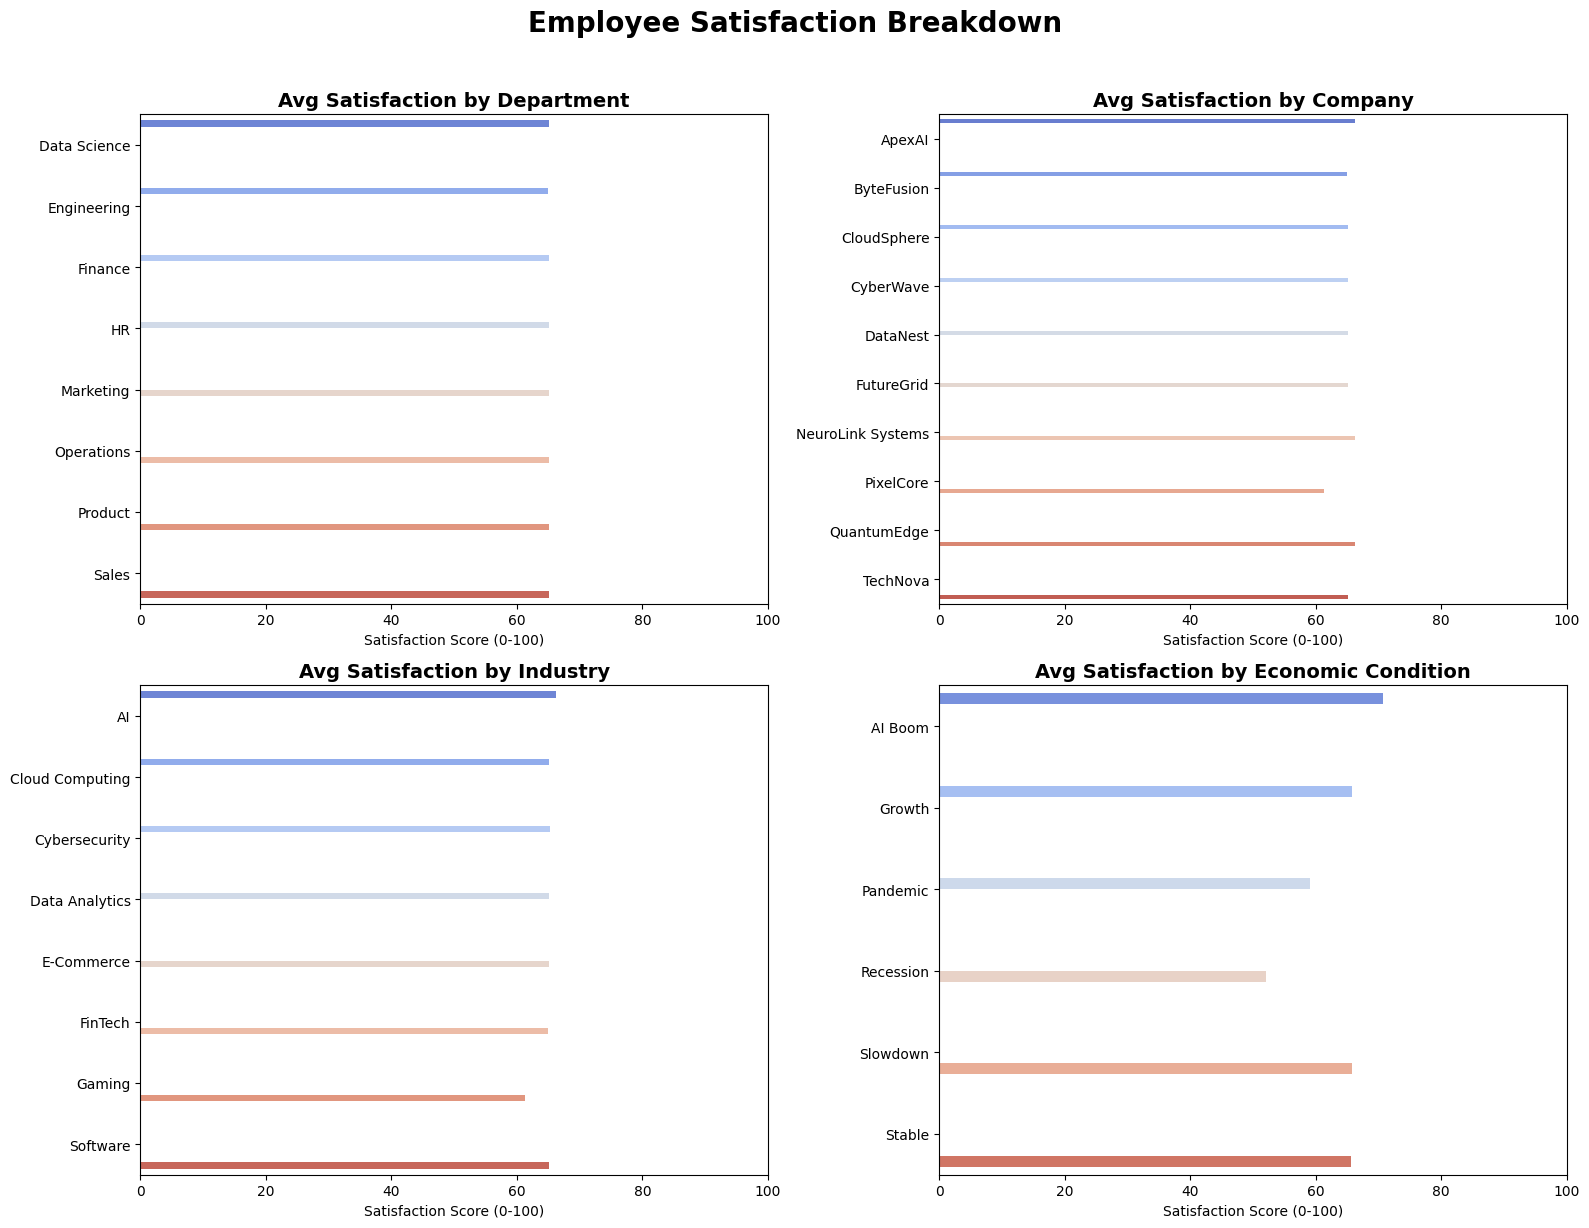

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the 4 categories you want to compare
categories = ['department', 'company', 'industry', 'economic_condition']

# 2. Set up a 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten the axes array to make it easy to loop through
axes = axes.flatten()

# 3. Loop through the categories and create a Horizontal Bar Chart for each
for i, cat in enumerate(categories):
    # Calculate the average satisfaction for this category, sorted from highest to lowest
    avg_satisfaction = df.groupby(cat)['employee_satisfaction'].mean().sort_values(ascending=False).reset_index()
    
    # Draw the barplot
    sns.barplot(data=avg_satisfaction, 
                x='employee_satisfaction', 
                y=cat, 
                ax=axes[i], 
                palette='coolwarm',
                hue=cat, 
                legend=False)
    
    # Formatting
    axes[i].set_title(f'Avg Satisfaction by {cat.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Satisfaction Score (0-100)', fontsize=10)
    axes[i].set_ylabel('') # Hides the y-axis label to keep it clean
    axes[i].set_xlim(0, 100) # Locks the x-axis to 100 so all 4 charts use the exact same scale!

plt.suptitle('Employee Satisfaction Breakdown', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Phase 3: Statistics and Statistical Tests

Randomly selected companies: NeuroLink Systems vs CyberWave


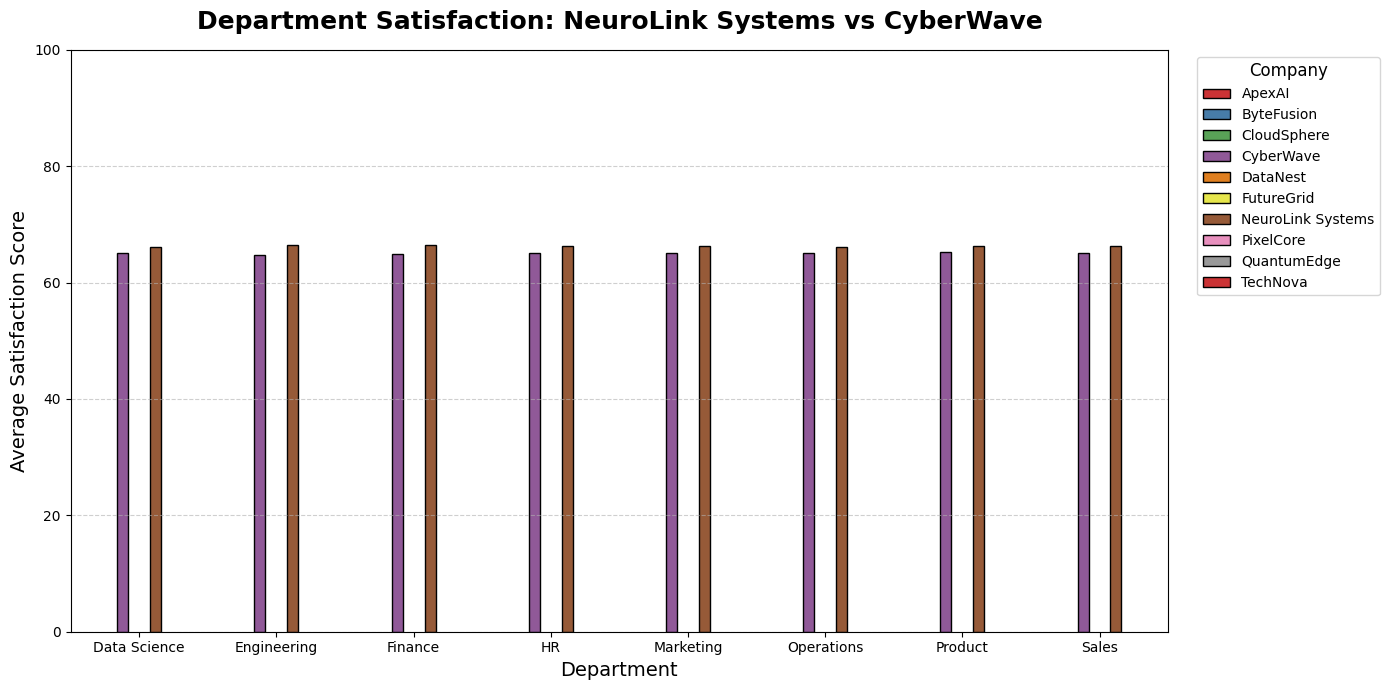

In [40]:

# 1. Pick 2 random companies from the dataset
# Note: I used random_state=42 so it picks the same 2 for testing. Remove 'random_state=42' for true randomness every run!
random_companies = df['company'].drop_duplicates().sample(2, random_state=42).tolist()
print(f"Randomly selected companies: {random_companies[0]} vs {random_companies[1]}")

# 2. Filter the dataset to only include those 2 companies
df_two_companies = df[df['company'].isin(random_companies)]

# 3. Calculate the average satisfaction per department for these 2 companies
dept_satisfaction = df_two_companies.groupby(['department', 'company'])['employee_satisfaction'].mean().reset_index()

# 4. Set up and draw the Grouped Bar Chart
plt.figure(figsize=(14, 7))

# By assigning x='department' and hue='company', Seaborn automatically puts the bars side-by-side!
sns.barplot(data=dept_satisfaction, 
            x='department', 
            y='employee_satisfaction', 
            hue='company', 
            palette='Set1',
            edgecolor='black') # Adds a crisp border to the bars

# 5. Professional Formatting
plt.title(f'Department Satisfaction: {random_companies[0]} vs {random_companies[1]}', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Department', fontsize=14)
plt.ylabel('Average Satisfaction Score', fontsize=14)
plt.ylim(0, 100) # Locks the Y-axis to 100 since it's a 0-100 score

# Move the legend outside the chart so it doesn't cover up any bars
plt.legend(title='Company', title_fontsize=12, fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
